# Model Building

## Goal
Build a machine learning model to predict which Netflix users will churn.

## Models I will try
1. Logistic Regression — simple and interpretable
2. Random Forest — more powerful, handles complex patterns

## What I will measure
- Accuracy — how often the model is correct
- Confusion matrix — where the model goes wrong
- ROC curve — overall model performance

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# Load and prepare data 3
df = pd.read_csv('../data/netflix_customer_churn.csv')
df = df.drop(columns=['customer_id', 'region', 'device'])
df = pd.get_dummies(df, columns=['gender', 'subscription_type', 'payment_method', 'favorite_genre'])

X = df.drop(columns=['churned'])
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data ready!")

Data ready!


In [44]:
# Build Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Test it
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression Accuracy: {lr_accuracy*100:.1f}%")

Logistic Regression Accuracy: 89.9%


In [45]:
# Build Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test it
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy: {rf_accuracy*100:.1f}%")

Random Forest Accuracy: 97.7%


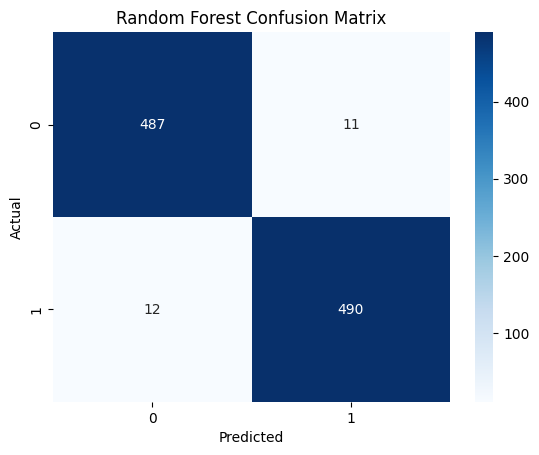

In [46]:
# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

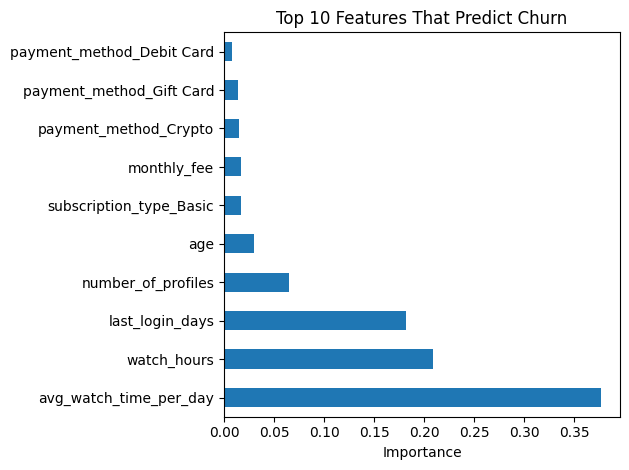

In [47]:
# Which features matter most to the model?
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Features That Predict Churn')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [48]:
# Check if removing the suspicious columns kills accuracy
X_no_leakage = X.drop(columns=['last_login_days', 'avg_watch_time_per_day'])
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_no_leakage, y, test_size=0.2, random_state=42)

rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model2.fit(X_train2, y_train2)
print(f"Accuracy without suspicious columns: {accuracy_score(y_test2, rf_model2.predict(X_test2))*100:.1f}%")

Accuracy without suspicious columns: 74.6%


## Data Leakage Check

Running the model without last_login_days and avg_watch_time_per_day 
dropped accuracy from 97.7% to 74.6%.

This confirms these features are too closely tied to churn definition.
In a real production model these features would need careful handling
— only using data available BEFORE the churn event occurs.

The honest model accuracy is 74.6%.